<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Critical_Infrastructure_Dependency_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Critical Infrastructure Dependency Graph
This notebook models the interdependencies between different infrastructure sectors to study cascading failures and system resilience.

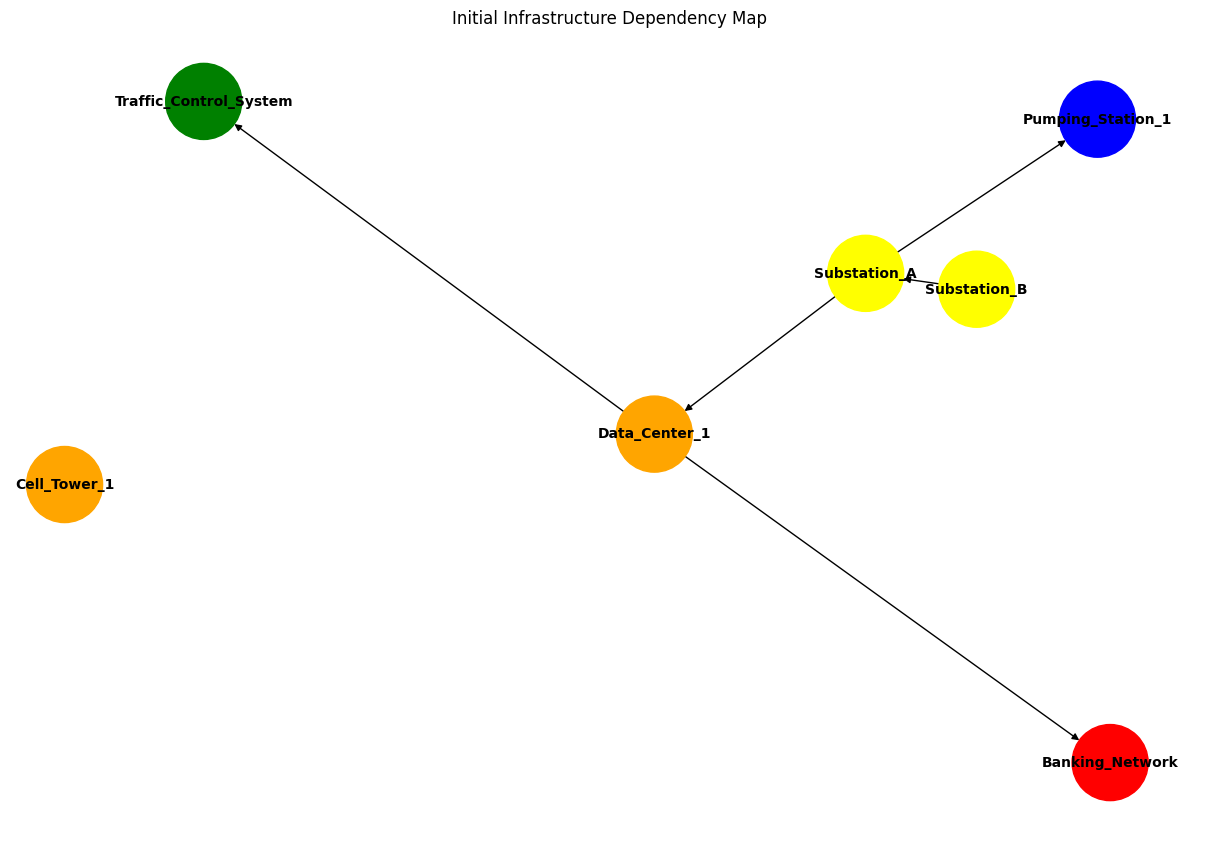

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize the directed graph
G = nx.DiGraph()

# Define sectors and their nodes
infrastructure = {
    'Power': ['Substation_A', 'Substation_B'],
    'Telecom': ['Data_Center_1', 'Cell_Tower_1'],
    'Water': ['Pumping_Station_1'],
    'Transportation': ['Traffic_Control_System'],
    'Finance': ['Banking_Network']
}

# Add nodes with sector attributes
for sector, nodes in infrastructure.items():
    for node in nodes:
        G.add_node(node, sector=sector)

# Define dependencies (A depends on B means an edge B -> A)
dependencies = [
    ('Substation_A', 'Data_Center_1'), # Telecom needs Power
    ('Substation_A', 'Pumping_Station_1'), # Water needs Power
    ('Data_Center_1', 'Banking_Network'), # Finance needs Telecom
    ('Data_Center_1', 'Traffic_Control_System'), # Transportation needs Telecom
    ('Substation_B', 'Substation_A') # Grid redundancy/link
]

G.add_edges_from(dependencies)

# Visualize the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# Color nodes by sector
colors = {'Power': 'yellow', 'Telecom': 'orange', 'Water': 'blue', 'Transportation': 'green', 'Finance': 'red'}
node_colors = [colors[G.nodes[n]['sector']] for n in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=3000, font_size=10, font_weight='bold', arrows=True)
plt.title("Initial Infrastructure Dependency Map")
plt.show()

### Next Steps
1. Identify critical nodes using centrality measures.
2. Simulate a failure (e.g., removing a power node) to observe cascading effects.

## 1. Critical Node Identification
We'll use **Degree Centrality** and **Betweenness Centrality** to find nodes that are most vital to the network's connectivity.

In [2]:
degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

print("Criticality Scores:")
for node in G.nodes():
    print(f"{node:25} | Degree: {degree[node]:.2f} | Betweenness: {betweenness[node]:.2f}")

Criticality Scores:
Substation_A              | Degree: 0.50 | Betweenness: 0.13
Substation_B              | Degree: 0.17 | Betweenness: 0.00
Data_Center_1             | Degree: 0.50 | Betweenness: 0.13
Cell_Tower_1              | Degree: 0.00 | Betweenness: 0.00
Pumping_Station_1         | Degree: 0.17 | Betweenness: 0.00
Traffic_Control_System    | Degree: 0.17 | Betweenness: 0.00
Banking_Network           | Degree: 0.17 | Betweenness: 0.00


## 2. Simulating Cascading Failure
If a power node fails, all nodes depending on it (directly or indirectly) will lose service.

--- FAILURE SIMULATION: Substation_A ---
Initial Failure: Substation_A
Cascading Impact: ['Pumping_Station_1', 'Banking_Network', 'Traffic_Control_System', 'Data_Center_1']


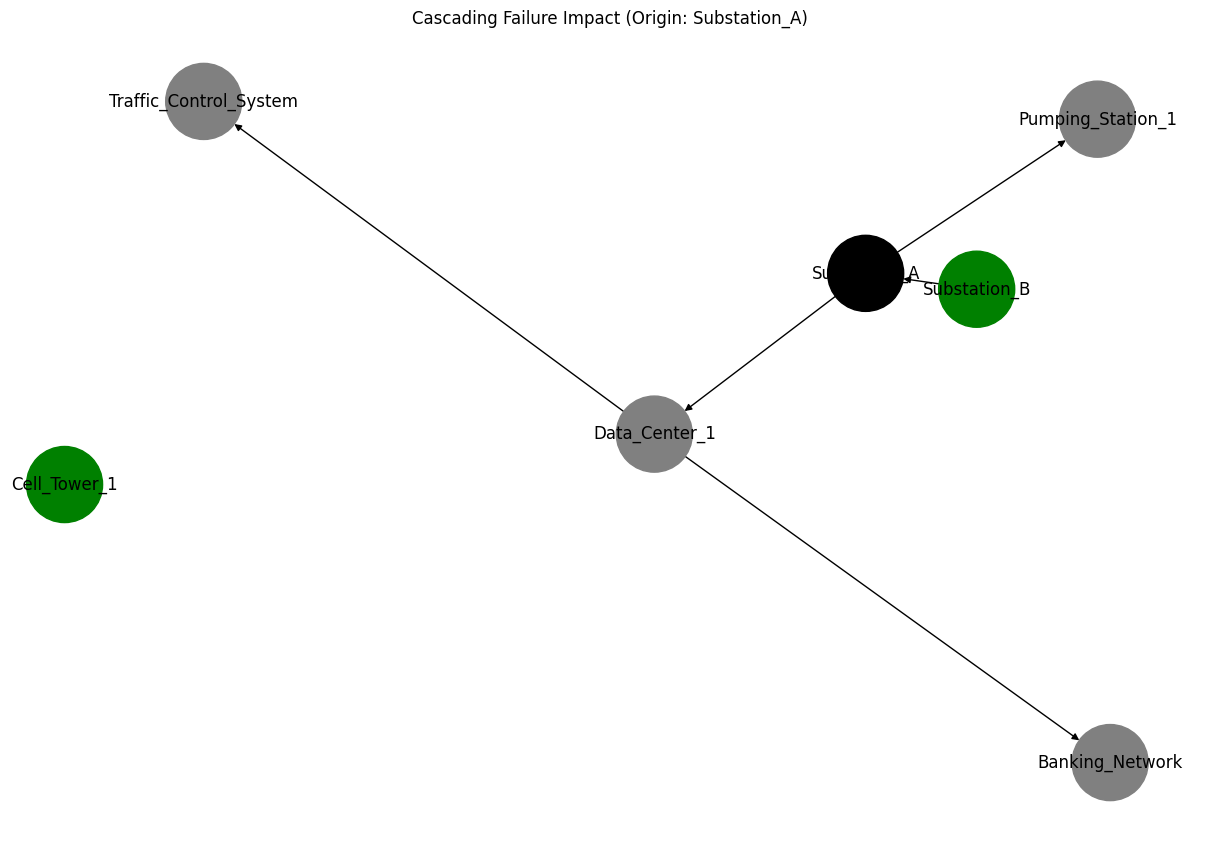

In [3]:
failed_node = 'Substation_A'

# Identify all nodes reachable from the failed node in the dependency direction
# (In our graph, B -> A means A depends on B)
affected_nodes = nx.descendants(G, failed_node)

print(f"--- FAILURE SIMULATION: {failed_node} ---")
print(f"Initial Failure: {failed_node}")
print(f"Cascading Impact: {list(affected_nodes)}")

# Visualizing the impact
node_colors_impact = []
for n in G.nodes():
    if n == failed_node:
        node_colors_impact.append('black') # Primary failure
    elif n in affected_nodes:
        node_colors_impact.append('gray')  # Cascaded failure
    else:
        node_colors_impact.append('green') # Still operational

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors_impact, node_size=3000, arrows=True)
plt.title(f"Cascading Failure Impact (Origin: {failed_node})")
plt.show()